# Gradient Descent 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ------------------------------------------------------------
# 1. Create a reproducible dataset
# ------------------------------------------------------------

print("=" * 60)
print("1. CREATE DATASET")
print("=" * 60)

np.random.seed(42)

N = 500

x = np.random.uniform(1, 10, N)
noise = np.random.normal(0, 1, N)
y = 1 + 2 * x + noise

print(f"Dataset size: {N} observations")
print("Relationship used to create the data: y = 1 + 2x + noise")
print("The noise makes the data more realistic.")


1. CREATE DATASET
Dataset size: 500 observations
Relationship used to create the data: y = 1 + 2x + noise
The noise makes the data more realistic.


In [3]:
# ------------------------------------------------------------
# 2. Initialize the model
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("2. INITIALIZE THE MODEL")
print("=" * 60)

w0 = 20.0
w1 = -5.0

learning_rate = 0.01
epochs = 1800

print(f"Starting w0 (intercept): {w0}")
print(f"Starting w1 (slope):     {w1}")
print(f"Learning rate:           {learning_rate}")
print(f"Number of epochs:        {epochs}")

print("\nGradient Descent will repeatedly adjust w0 and w1")
print("to reduce the Mean Squared Error (MSE).")


2. INITIALIZE THE MODEL
Starting w0 (intercept): 20.0
Starting w1 (slope):     -5.0
Learning rate:           0.01
Number of epochs:        1800

Gradient Descent will repeatedly adjust w0 and w1
to reduce the Mean Squared Error (MSE).


In [4]:
# ------------------------------------------------------------
# 3. Gradient Descent
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("3. GRADIENT DESCENT")
print("=" * 60)

print("Each epoch follows this process:")
print("Predict -> Calculate errors -> Calculate gradients")
print("-> Update w0 and w1 -> Calculate MSE")

loss_history = []

checkpoints = {1, 10, 50, 100, 250, 500, 1000, 1500, 1550, 1600, 1650, 1700, 1750, 1800}

print()
print(f"{'Epoch':>8} {'w0':>12} {'w1':>12} {'MSE':>12}")
print("-" * 48)

for epoch in range(1, epochs + 1):

    # Predict
    y_pred = w0 + w1 * x

    # Error
    errors = y_pred - y

    # Gradients
    grad_w0 = (2 / N) * np.sum(errors)
    grad_w1 = (2 / N) * np.sum(errors * x)

    # Update parameters
    w0 -= learning_rate * grad_w0
    w1 -= learning_rate * grad_w1

    # Calculate MSE
    y_pred = w0 + w1 * x
    mse = np.mean((y_pred - y) ** 2)

    loss_history.append(mse)

    # Print selected training steps
    if epoch in checkpoints:
        print(
            f"{epoch:>8}"
            f"{w0:>12.4f}"
            f"{w1:>12.4f}"
            f"{mse:>12.4f}"
        )



3. GRADIENT DESCENT
Each epoch follows this process:
Predict -> Calculate errors -> Calculate gradients
-> Update w0 and w1 -> Calculate MSE

   Epoch           w0           w1          MSE
------------------------------------------------
       1     20.3883     -1.8558    112.8098
      10     19.8730     -0.7830     70.8186
      50     17.1996     -0.3880     52.5599
     100     14.3802      0.0287     36.2977
     250      8.5208      0.8946     12.3281
     500      3.8347      1.5871      2.7092
    1000      1.3135      1.9596      1.0459
    1500      0.9344      2.0156      1.0083
    1550      0.9229      2.0174      1.0080
    1600      0.9133      2.0188      1.0078
    1650      0.9054      2.0199      1.0077
    1700      0.8988      2.0209      1.0076
    1750      0.8934      2.0217      1.0076
    1800      0.8889      2.0224      1.0075


In [5]:
# ------------------------------------------------------------
# 4. Final result
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("4. FINAL MODEL")
print("=" * 60)

print(f"Final w0:  {w0:.4f}")
print(f"Final w1:  {w1:.4f}")
print(f"Final MSE: {loss_history[-1]:.4f}")

print(f"\nFinal model: y_hat = {w0:.4f} + {w1:.4f}x")

print("\nInterpretation:")
print("Gradient Descent has adjusted the starting weights")
print("to find a line that produces a much lower MSE.")



4. FINAL MODEL
Final w0:  0.8889
Final w1:  2.0224
Final MSE: 1.0075

Final model: y_hat = 0.8889 + 2.0224x

Interpretation:
Gradient Descent has adjusted the starting weights
to find a line that produces a much lower MSE.



5. VISUAL RESULTS
The first plot shows the data and the line
learned by Gradient Descent.

The second plot shows MSE across epochs.
As Gradient Descent learns, MSE decreases.
A flatter curve means the model is approaching convergence.


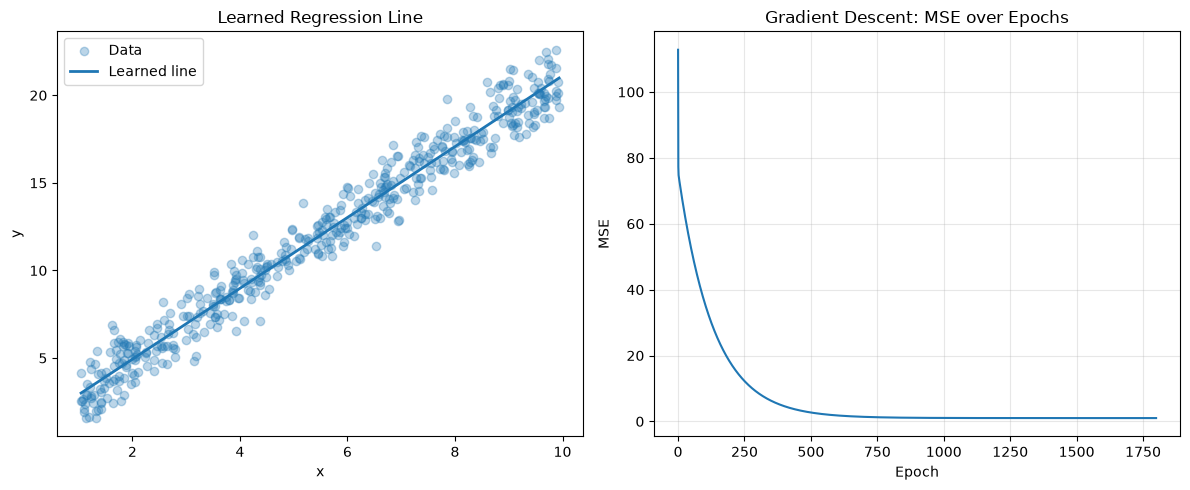

In [6]:
# ------------------------------------------------------------
# 5. Visual results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("5. VISUAL RESULTS")
print("=" * 60)

print("The first plot shows the data and the line")
print("learned by Gradient Descent.")

print("\nThe second plot shows MSE across epochs.")
print("As Gradient Descent learns, MSE decreases.")
print("A flatter curve means the model is approaching convergence.")


# Create the learned regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = w0 + w1 * x_line


# Create both plots in one window
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# ------------------------------------------------------------
# Plot 1: Learned regression line
# ------------------------------------------------------------

axes[0].scatter(x, y, alpha=0.3, label="Data")
axes[0].plot(x_line, y_line, linewidth=2, label="Learned line")

axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Learned Regression Line")
axes[0].legend()


# ------------------------------------------------------------
# Plot 2: Loss curve
# ------------------------------------------------------------

axes[1].plot(loss_history)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].set_title("Gradient Descent: MSE over Epochs")
axes[1].grid(alpha=0.3)


# Display both plots together
plt.tight_layout()
plt.show()